In [1]:
import os

for root, dirs, files in os.walk(r"E:\7th sem\pro\dataset5"):
    print(root)

E:\7th sem\pro\dataset5
E:\7th sem\pro\dataset5\fake
E:\7th sem\pro\dataset5\real


In [2]:
fake_count = len(os.listdir(r"E:\7th sem\pro\dataset5\fake"))
real_count = len(os.listdir(r"E:\7th sem\pro\dataset5\real"))

print("Fake Images:", fake_count)
print("Real Images:", real_count)

Fake Images: 700
Real Images: 589


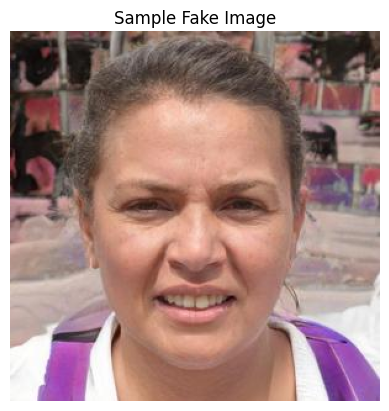

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import random

folder = r"E:\7th sem\pro\dataset5\fake"

img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Fake Image")
plt.axis("off")
plt.show()

In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_dir = r"E:\7th sem\pro\dataset5"

classes = ["real", "fake"]

for cls in classes:
    files = os.listdir(os.path.join(source_dir, cls))

    train_files, valid_files = train_test_split(
        files,
        test_size=0.2,
        random_state=42
    )

    os.makedirs(f"data/train/{cls}", exist_ok=True)
    os.makedirs(f"data/valid/{cls}", exist_ok=True)

    for file in train_files:
        shutil.copy(
            os.path.join(source_dir, cls, file),
            os.path.join(f"data/train/{cls}", file)
        )

    for file in valid_files:
        shutil.copy(
            os.path.join(source_dir, cls, file),
            os.path.join(f"data/valid/{cls}", file)
        )

print("Dataset split completed!")

Dataset split completed!


In [5]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: NVIDIA GeForce GTX 1650


In [6]:
import os

print("Train Fake:", len(os.listdir("data/train/fake")))
print("Train Real:", len(os.listdir("data/train/real")))

print("Valid Fake:", len(os.listdir("data/valid/fake")))
print("Valid Real:", len(os.listdir("data/valid/real")))

Train Fake: 560
Train Real: 471
Valid Fake: 140
Valid Real: 118


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root="data/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="data/valid",
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

print("Classes:", train_dataset.classes)

images, labels = next(iter(train_loader))

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Classes: ['fake', 'real']
Images Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


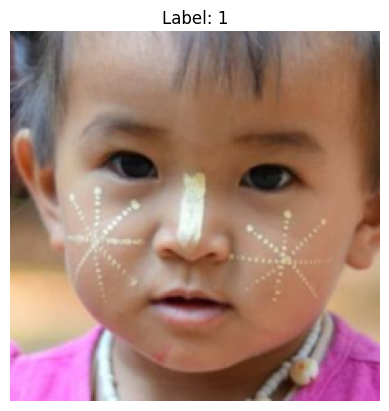

In [8]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [9]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Datasets
train_dataset = datasets.ImageFolder(
    root="data/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="data/valid",
    transform=valid_transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights="DEFAULT")

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\singh/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:23<00:00, 898kB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [11]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/5] Loss: 0.3297
Epoch [2/5] Loss: 0.0469
Epoch [3/5] Loss: 0.0266
Epoch [4/5] Loss: 0.0144
Epoch [5/5] Loss: 0.0083


In [16]:
torch.save(
    model.state_dict(),
    r"E:\7th sem\pro\dataset5\efficientnet_b0.pth"
)

print("Model Saved")

Model Saved


In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 99.61%


In [19]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model.load_state_dict(
    torch.load(
        r"E:\7th sem\pro\dataset5\efficientnet_b0.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

# Image Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Image Path
image_path = r"E:\7th sem\pro\dataset5\real\real_40.jpg"

# Load Image
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

classes = ['fake', 'real']

print(f"Prediction: {classes[predicted.item()]}")
print(f"Confidence: {confidence.item()*100:.2f}%")

Prediction: real
Confidence: 99.82%


In [21]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=["fake", "real"]
))

              precision    recall  f1-score   support

        fake       0.99      1.00      1.00       140
        real       1.00      0.99      1.00       118

    accuracy                           1.00       258
   macro avg       1.00      1.00      1.00       258
weighted avg       1.00      1.00      1.00       258



In [25]:
pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 840.2 kB/s eta 0:00:09
     -- ------------------------------------- 0.5/7.8 MB 840.2 kB/s eta 0:00:09
     ---- ----------------------------------- 0.8/7.8 MB 907.1 kB/s eta 0:00:08
     ---- ----------------------------------- 0.8/7.8 MB 907.1 kB/s eta 0:00:08
     ----- ---------------------------------- 1.0/7.8 MB 799.2 kB/s eta 0:00:09
     ----- ---------------------------------- 1.0/7.8 MB 799.2 kB/s eta 0:00:09
     ------ --------------------------------- 1.3/7.8 MB 762.6 kB/s eta 0:00:09
     -------- ------------------------------- 1.6/7.8 MB 755.9 kB/s eta 0:00:09
     -------- ------------------------------- 1.6/7.8 MB 755.9 kB/s eta 0:00:09
     --------- ------------------------------ 1.8/7.8 MB 768.4 kB/s

In [26]:
from pytorch_grad_cam import GradCAM

print("Grad-CAM installed successfully")

Grad-CAM installed successfully


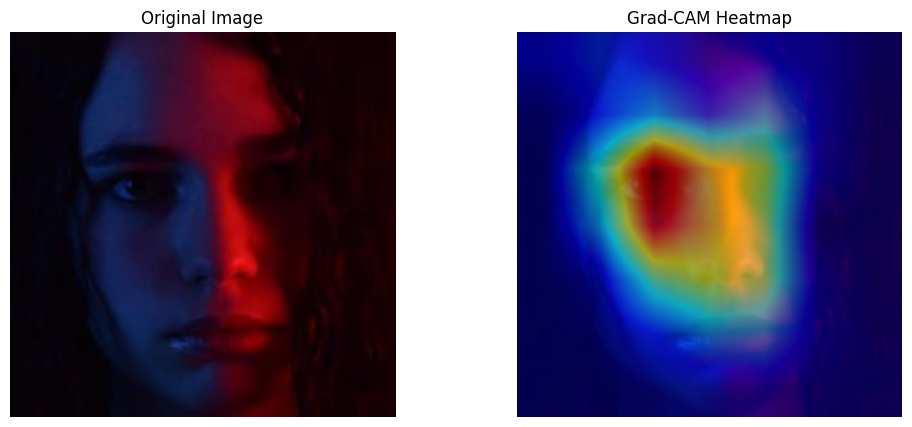

In [28]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model.load_state_dict(
    torch.load(
        r"E:\7th sem\pro\dataset5\efficientnet_b0.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

# Image path
image_path = r"E:\7th sem\pro\dataset5\real\real_31.jpg"

# Original image
rgb_img = np.array(Image.open(image_path).convert("RGB"))
rgb_img = cv2.resize(rgb_img, (224, 224))

# Normalize to [0,1]
rgb_float = rgb_img.astype(np.float32) / 255.0

transform = transforms.Compose([
    transforms.ToTensor(),
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# Last convolutional layer of EfficientNet-B0
target_layers = [model.features[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

visualization = show_cam_on_image(
    rgb_float,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.show()

In [29]:
import sys
print(sys.executable)

D:\anaconda\envs\pytorch-gpu\python.exe
